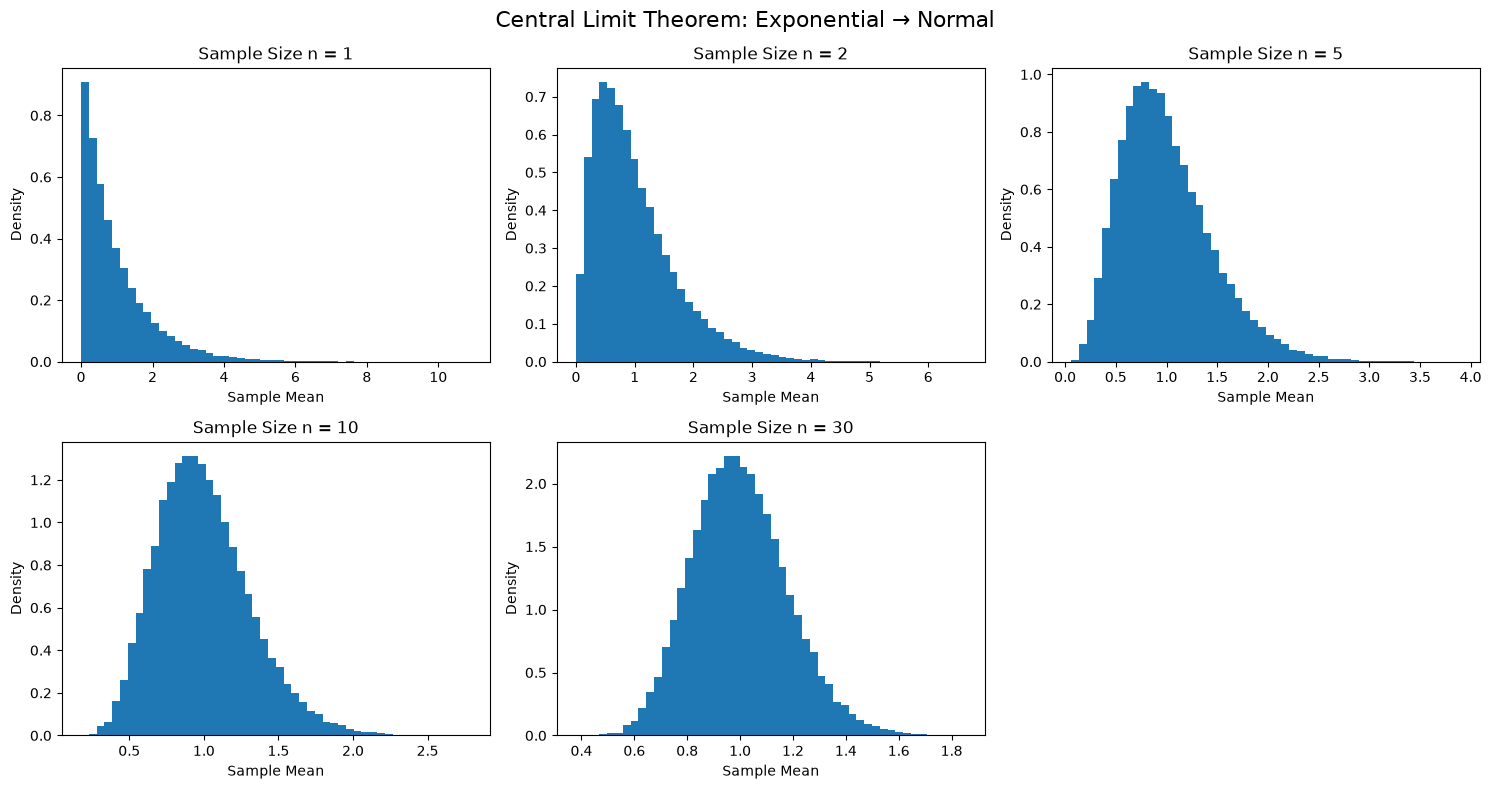

SAMPLE MEAN DISTRIBUTIONS
------------------------------------------------------------

n = 1
Mean of averages        : 1.0005
Theoretical mean        : 1.0000
SD of averages          : 1.0051
CLT predicted SD        : 1.0000

n = 2
Mean of averages        : 0.9966
Theoretical mean        : 1.0000
SD of averages          : 0.7097
CLT predicted SD        : 0.7071

n = 5
Mean of averages        : 1.0016
Theoretical mean        : 1.0000
SD of averages          : 0.4499
CLT predicted SD        : 0.4472

n = 10
Mean of averages        : 0.9983
Theoretical mean        : 1.0000
SD of averages          : 0.3150
CLT predicted SD        : 0.3162

n = 30
Mean of averages        : 1.0000
Theoretical mean        : 1.0000
SD of averages          : 0.1810
CLT predicted SD        : 0.1826


√n SPREAD-SHRINKING CHECK
------------------------------------------------------------
n =  1 | Observed SD = 1.0051 | SD × √n = 1.0051
n =  2 | Observed SD = 0.7097 | SD × √n = 1.0037
n =  5 | Observed SD = 0.4499

In [1]:
# TASK 03 — VERIFY THE CENTRAL LIMIT THEOREM (CLT)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Fixed seed -> reproducible random results
rng = np.random.default_rng(0)

# Number of repeated samples/averages
reps = 50_000

# We start with an exponential distribution.
# Exponential is skewed and NOT normally distributed.
scale = 1

# Sample sizes we want to investigate
sample_sizes = [1, 2, 5, 10, 30]

# 1. FUNCTION TO GENERATE DISTRIBUTION OF SAMPLE MEANS

def sample_means(n, reps=50_000):
    """
    Generate 'reps' sample means.

    For every repetition:
    - Draw n exponential values.
    - Calculate their average.
    - Store that average.

    The collection of averages is the sampling distribution
    of the sample mean.
    """

    # Generate all values at once for faster computation.
    samples = rng.exponential(scale, size=(reps, n))

    # Average each row.
    # axis=1 means calculate the mean across the n observations.
    return samples.mean(axis=1)

# 2. GENERATE SAMPLE MEANS FOR DIFFERENT SAMPLE SIZES

mean_distributions = {}

for n in sample_sizes:
    mean_distributions[n] = sample_means(n, reps)

# 3. PLOT HISTOGRAMS

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, n in zip(axes.flat, sample_sizes):

    means = mean_distributions[n]

    ax.hist(means, bins=50, density=True)

    ax.set_title(f"Sample Size n = {n}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Density")

# We have 5 plots, so hide the unused sixth subplot.
axes[1, 2].axis("off")

plt.suptitle(
    "Central Limit Theorem: Exponential → Normal",
    fontsize=16
)

plt.tight_layout()
plt.show()

# 4. CHECK MEAN AND STANDARD DEVIATION

print("SAMPLE MEAN DISTRIBUTIONS")
print("-" * 60)

# For Exponential(scale=1):
# Theoretical population mean = scale = 1
# Theoretical population variance = scale² = 1
# Therefore population standard deviation = 1

population_mean = scale
population_sd = scale

for n in sample_sizes:

    means = mean_distributions[n]

    sample_mean = means.mean()
    sample_sd = means.std()

    # CLT prediction:
    # SD of sample mean = population SD / sqrt(n)
    theoretical_sd = population_sd / np.sqrt(n)

    print(f"\nn = {n}")
    print(f"Mean of averages        : {sample_mean:.4f}")
    print(f"Theoretical mean        : {population_mean:.4f}")
    print(f"SD of averages          : {sample_sd:.4f}")
    print(f"CLT predicted SD        : {theoretical_sd:.4f}")

# 5. NUMERICALLY VERIFY THE √n SPREAD SHRINKING

print("\n\n√n SPREAD-SHRINKING CHECK")
print("-" * 60)

for n in sample_sizes:

    means = mean_distributions[n]

    observed_sd = means.std()

    # Multiply observed SD by sqrt(n).
    # If CLT is working, this should stay close to
    # the original population SD = 1.
    scaled_sd = observed_sd * np.sqrt(n)

    print(
        f"n = {n:2d} | "
        f"Observed SD = {observed_sd:.4f} | "
        f"SD × √n = {scaled_sd:.4f}"
    )


# 6. COMPARE OBSERVED SD WITH CLT PREDICTION

print("\n\nCLT PREDICTION CHECK")
print("-" * 60)

for n in sample_sizes:

    observed_sd = mean_distributions[n].std()

    predicted_sd = population_sd / np.sqrt(n)

    error = abs(observed_sd - predicted_sd)

    print(
        f"n = {n:2d} | "
        f"Observed = {observed_sd:.4f} | "
        f"Predicted = {predicted_sd:.4f} | "
        f"Difference = {error:.4f}"
    )


# 7. OPTIONAL: SHOW HOW SKEWNESS CHANGES

print("\n\nSKEWNESS CHECK")
print("-" * 60)

for n in sample_sizes:

    means = mean_distributions[n]

    # Skewness measures asymmetry.
    # Lower skewness means the distribution is becoming
    # more symmetric/bell-shaped.
    skewness = stats.skew(means)

    print(f"n = {n:2d} | Skewness = {skewness:.4f}")

# TASK 03 — Verify the Central Limit Theorem (CLT)


The goal is to empirically verify the **Central Limit Theorem (CLT)** by starting with a non-normal distribution (Exponential) and observing how the distribution of sample means becomes approximately normal as the sample size increases.

## 1. Starting Distribution

We use an **Exponential distribution** with:

- Scale = 1
- Population Mean = 1
- Population Variance = 1
- Population Standard Deviation = 1

The Exponential distribution is **right-skewed**, so it is a good example for observing the CLT.


## 2. Experiment Setup

We generate:

- **50,000 repetitions**
- Sample sizes: **n = 1, 2, 5, 10, 30**

For every repetition:

1. Generate `n` random observations from the exponential distribution.
2. Calculate their mean.
3. Store the mean.
4. Repeat this process 50,000 times.

The resulting collection of means is called the **sampling distribution of the sample mean**.


## 3. Expected CLT Behaviour

As `n` increases:

| Sample Size | Expected Behaviour |
|---:|---|
| 1 | Looks like the original exponential distribution |
| 2 | Starts becoming less skewed |
| 5 | More symmetric |
| 10 | Noticeably more bell-shaped |
| 30 | Approximately normal/bell-shaped |

Therefore:

> As the sample size increases, the distribution of sample means becomes increasingly close to a normal distribution.


## 4. CLT Spread Prediction

The standard deviation of the sample mean is:

\[
SD_{\bar X} = \frac{\sigma}{\sqrt{n}}
\]

Our exponential distribution has:

\[
\sigma = 1
\]

Therefore:

| n | Theoretical SD of Sample Mean |
|---:|---:|
| 1 | 1.0000 |
| 2 | 0.7071 |
| 5 | 0.4472 |
| 10 | 0.3162 |
| 30 | 0.1826 |

The observed standard deviations from the simulation should be close to these theoretical values.


## 5. Numerical Verification of √n Relationship

The CLT predicts:

\[
SD_{\bar X} = \frac{\sigma}{\sqrt n}
\]

Rearranging:

\[
SD_{\bar X}\sqrt n \approx \sigma
\]

Since our population standard deviation is 1:

\[
SD_{\bar X}\sqrt n \approx 1
\]

Therefore, multiplying the observed standard deviation of the sample means by `√n` should give a value close to **1** for every sample size.


## 6. Why Does the Bell Shape Appear?

The original exponential distribution is not normal; it is strongly right-skewed.

However, when we repeatedly calculate averages of many independent observations, high and low random values tend to balance each other.

As the sample size increases, the distribution of these averages becomes more symmetric and approaches a normal distribution.

This is the main idea of the **Central Limit Theorem**.


# LOOKUP QUESTIONS

## Q1. Why does averaging turn any starting distribution into a bell?

The Central Limit Theorem states that the distribution of sample means approaches a normal distribution as the sample size becomes sufficiently large, provided the observations satisfy the required independence and finite-variance conditions.

The original distribution does not become normal. Instead, the **sampling distribution of the mean** becomes approximately normal.



## Q2. Why does the spread of the averages shrink by √n?

The standard deviation of the sample mean is:

\[
SD_{\bar X} = \frac{\sigma}{\sqrt n}
\]

As `n` increases, `√n` also increases, causing the standard deviation of the sample mean to decrease.

Therefore, larger samples produce averages that fluctuate less from sample to sample.


## Q3. Why do bigger samples give more reliable estimates?

A larger sample contains more observations, so random fluctuations have less influence on the final average.

Because:

\[
SD_{\bar X} = \frac{\sigma}{\sqrt n}
\]

the uncertainty in the sample mean decreases as the sample size increases.

Therefore, larger samples generally provide more stable estimates of the population mean.


## Q4. Where is the CLT used in Machine Learning and Data Science?

The CLT is useful in:

- Statistical inference
- Confidence intervals
- Hypothesis testing
- A/B testing
- Sampling
- Estimating population parameters
- Comparing average model performance
- Model evaluation
- Statistical analysis of datasets
- Understanding sampling distributions

## Q5. Why does the normal distribution appear so often in nature?

Many real-world quantities are affected by many small random factors.

When these independent effects are combined or averaged, the resulting distribution often becomes approximately normal.

The Central Limit Theorem provides the mathematical explanation for why normal distributions frequently appear when dealing with sums and averages.

## 7. Important Distinction

### Incorrect:

> The exponential distribution becomes normal.

### Correct:

> The distribution of the **sample means obtained from the exponential distribution** becomes approximately normal as the sample size increases.

The original population remains exponential.

---

## 8. Skewness Observation

The exponential distribution has positive/right skewness.

As the sample size increases:

- `n = 1` → highly skewed
- `n = 2` → less skewed
- `n = 5` → more symmetric
- `n = 10` → close to bell-shaped
- `n = 30` → approximately normal

Therefore, the decreasing skewness supports the visual observation that the sampling distribution is becoming more normal.

